# 39 - Adam with L2 Regularization

**Section:** Metaparameters | **Prereqs:** `Metaparameters/RMSprop_and_Adam.ipynb` | **Next:** `Metaparameters/LearningRateDecay.ipynb`

Combining the two: `Adam(..., weight_decay=lambda)`, swept over six lambda values
on a deliberately tiny model (2-8-8-3).

**The point of the small model.** Regularisation only helps a model that is
overfitting. On 8-unit layers with 810 training samples there is barely anything
to over-fit, so the sweep mostly shows the *cost* of too much penalty - accuracy
falling as lambda grows. That is a useful thing to see: regularisation is not
free, and adding it to an underfitting model just makes it worse.

**A real subtlety - AdamW.** `weight_decay` in Adam adds the penalty to the
gradient, which then gets divided by Adam's per-parameter scaling. So parameters
with large gradients end up decayed *less* - the opposite of the intended
uniform shrinkage. `torch.optim.AdamW` applies the decay directly to the weights
instead, which is what the L2 math actually says, and is the recommended choice
whenever you want weight decay with Adam.

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

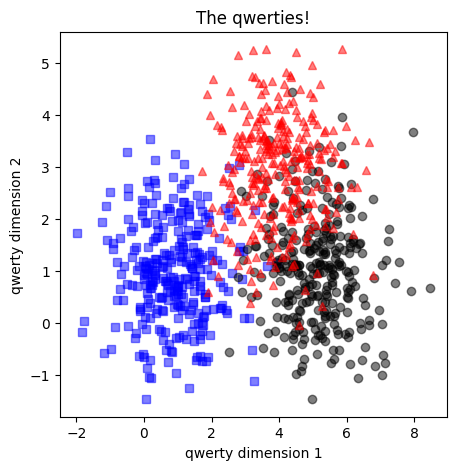

In [31]:
# The usual three clusters.
nPerClust = 300
blur = 1

A = [ 1, 1 ]
B = [ 5, 1 ]
C = [ 4, 3 ]

# generate data
a = [ A[0]+np.random.randn(nPerClust)*blur , A[1]+np.random.randn(nPerClust)*blur ]
b = [ B[0]+np.random.randn(nPerClust)*blur , B[1]+np.random.randn(nPerClust)*blur ]
c = [ C[0]+np.random.randn(nPerClust)*blur , C[1]+np.random.randn(nPerClust)*blur ]

# true labels
labels_np = np.hstack((  np.zeros((nPerClust)),
                         np.ones( (nPerClust)),
                       1+np.ones( (nPerClust))  ))

# concatanate into a matrix
data_np = np.hstack((a,b,c)).T

# convert to a pytorch tensor
data = torch.tensor(data_np).float()
labels = torch.tensor(labels_np).long() # note: "long" format for CCE

# show the data
fig = plt.figure(figsize=(5,5))
plt.plot(data[np.where(labels==0)[0],0],data[np.where(labels==0)[0],1],'bs',alpha=.5)
plt.plot(data[np.where(labels==1)[0],0],data[np.where(labels==1)[0],1],'ko',alpha=.5)
plt.plot(data[np.where(labels==2)[0],0],data[np.where(labels==2)[0],1],'r^',alpha=.5)
plt.title('The qwerties!')
plt.xlabel('qwerty dimension 1')
plt.ylabel('qwerty dimension 2')
plt.show()

In [32]:
from sklearn.model_selection import train_test_split
train_data,test_data, train_labels,test_labels = train_test_split(data, labels, test_size=.1)

# then convert them into PyTorch Datasets (note: already converted to tensors)
train_data = TensorDataset(train_data,train_labels)
test_data  = TensorDataset(test_data,test_labels)

# finally, translate into dataloader objects
batchsize    = 32
train_loader = DataLoader(train_data,batch_size=batchsize,shuffle=True,drop_last=True)
test_loader  = DataLoader(test_data,batch_size=test_data.tensors[0].shape[0])

In [37]:
# A deliberately tiny model - 2 -> 8 -> 8 -> 3 - so the effect of the penalty is
# not swamped by spare capacity.
# weight_decay=L2lambda is the whole implementation of L2, as in
# Regularization/Weight_Regularization_(L2).ipynb.
# For serious use prefer torch.optim.AdamW, which decouples the decay from
# Adam's adaptive scaling - see the intro.
epochs = 50


def create_model(L2lambda):
  model = nn.Sequential (
      nn.Linear(2,8),
      nn.ReLU(),
      nn.Linear(8,8),
      nn.ReLU(),
      nn.Linear(8,3)
  )

  lossFunc = nn.CrossEntropyLoss()

  lr =0.001

  optimizer = torch.optim.Adam(model.parameters(), lr = lr, weight_decay=L2lambda)


  return model, lossFunc, optimizer


In [38]:
# Standard training function taking the L2 strength.
def train_model(L2lambda):

  classifier , lossFunc, optimizer = create_model(L2lambda)

  test_acc = []
  train_acc = []
  losses = torch.zeros(epochs)

  for i in range(epochs):

    classifier.train()
    batch_acc = []
    batch_loss = []


    for x,y in train_loader:

      yhat = classifier(x)

      loss = lossFunc(yhat, y)
      batch_loss.append(loss.item())

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      batch_acc.append(100 * torch.mean((torch.argmax(yhat,dim=1) == y).float()))

    train_acc.append(np.mean(batch_acc))
    losses[i] = np.mean(batch_loss)

    classifier.eval()
    with torch.no_grad():
      X,Y = next(iter(test_loader))
      test_acc.append(100 * torch.mean((torch.argmax(classifier(X),dim=1) == Y).float()))


  return train_acc, test_acc, losses


In [39]:
# Six lambdas from 0 to 0.1. 0.1 is very strong; the top of the range is there
# to show the failure.
lambdas = np.linspace(0,.1,6)

final_test_acc = []
final_train_acc = []
final_losses = []

for i in lambdas:
  train ,test, loss = train_model(i)

  final_test_acc.append(test)
  final_train_acc.append(train)
  final_losses.append(loss)

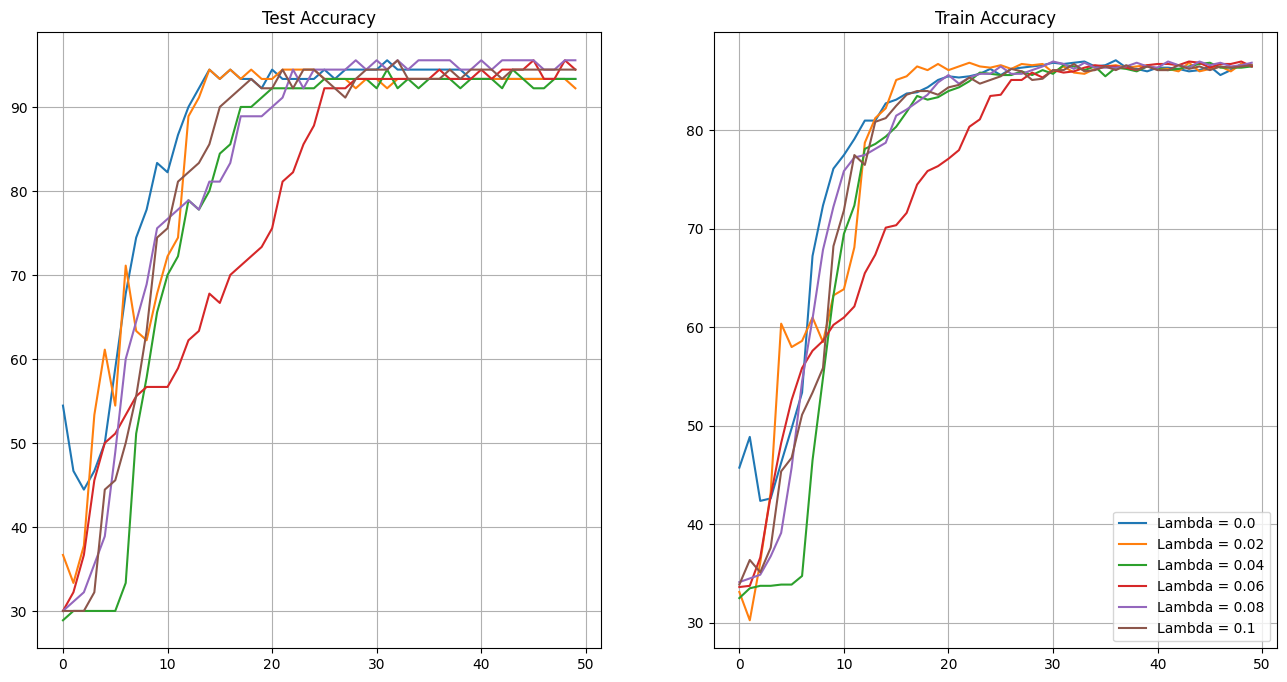

In [40]:
# Test and train accuracy per lambda. Expect a flat or slightly declining trend:
# on a model this small there is little overfitting for L2 to remove, so the
# penalty mostly costs capacity.
fig, ax = plt.subplots(1,2,figsize=(16,8))

for i in range(len(lambdas)):
  ax[0].plot(final_test_acc[i], label=f"Lambda = {lambdas[i]}")
  ax[1].plot(final_train_acc[i],label=f"Lambda = {lambdas[i]}")

ax[0].set_title("Test Accuracy")
ax[0].grid();
ax[1].set_title("Train Accuracy")
ax[1].grid();
plt.legend();